In [3]:
from google.colab import files
uploaded = files.upload()

Saving ParcelInvoice Dataset.csv to ParcelInvoice Dataset.csv


In [4]:
import pandas as pd
df = pd.read_csv("ParcelInvoice Dataset.csv")

In [5]:
df.sample(5)

,Tracking Number,Carrier Name,Service Level,Zones,Weight (lbs),Dimensions (in),Charge Type,Charge,Pickup Zipcode,Dropoff Zipcode,Date of Delivery
128,3F10987ZXCVB,Delhivery,Standard,4,5 lbs,12x12x8,Future Day Pickup - Large Package Surcharge-Or...,$30.00,75201,60605,2025-07-19
30,5F98765MNBVC,DTDC,Economy,5,4 lbs,12x12x8,Agri Processing Fee,$27.50,85005,20002,2024-05-20
1,1F1234567890123451,DTDC,Ground,Zone 4,5,12x12x8,Additional Tax,5.5,60606,90210,2023-08-14
195,0F76543LKJHG,FedEx,Economy,5,4 lbs,12x12x8,Future Day Pickup - Additional Handling - Week...,$25.00,60606,30301,2031-02-16
83,8F98765MNBVC,Delhivery,Standard,4,4 lbs,12x12x8,Delivery Confirmation Signature,$25.00,75201,60605,2023-10-17


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 214 entries, 0 to 213
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Tracking Number   214 non-null    object
 1   Carrier Name      214 non-null    object
 2   Service Level     214 non-null    object
 3   Zones             214 non-null    object
 4   Weight (lbs)      214 non-null    object
 5   Dimensions (in)   214 non-null    object
 6   Charge Type       214 non-null    object
 7   Charge            214 non-null    object
 8   Pickup Zipcode    214 non-null    int64 
 9   Dropoff Zipcode   214 non-null    int64 
 10  Date of Delivery  214 non-null    object
dtypes: int64(2), object(9)
memory usage: 18.5+ KB


In [7]:
df.nunique()

,0
Tracking Number,106
Carrier Name,9
Service Level,8
Zones,11
Weight (lbs),14
Dimensions (in),9
Charge Type,196
Charge,27
Pickup Zipcode,27
Dropoff Zipcode,30


In [8]:
df_unique = [[df["Carrier Name"].unique()], [df["Service Level"].unique()], [df["Zones"].unique()], [df["Dimensions (in)"].unique()], [df["Weight (lbs)"].unique()]]
df_unique

[[array(['Delhivery', 'DTDC', 'Blue Dart', 'FedEx', 'Gati',
         'Ekart Logistics', 'DHL', 'Ecom Express', 'Safe Express'],
        dtype=object)],
 [array(['Ground', '2Day', 'Next Day Air', 'Standard', 'Express',
         'Priority', 'Economy', 'Expedited'], dtype=object)],
 [array(['Zone 6', 'Zone 4', 'Zone 3', 'Zone 1', 'Zone 2', 'Zone 5', '3',
         '2', '4', '1', '5'], dtype=object)],
 [array(['12x12x8', '10x10x6', '12x10x6', '14x14x10', '16x16x12', '12x8x6',
         '12x10x8', '14x12x10', '14x12x8'], dtype=object)],
 [array(['11', '5', '12', '7', '8', '6', '10', '9', '4', '4 lbs', '5 lbs',
         '6 lbs', '7 lbs', '8 lbs'], dtype=object)]]

In [9]:
df["Charge"] = df["Charge"].replace("[$,]", "", regex=True).astype(float)
df["Weight (lbs)"] = df["Weight (lbs)"].astype(str).str.replace(" lbs","").astype(float)
df["Date of Delivery"] = pd.to_datetime(df["Date of Delivery"])
df["Carrier Name"] = df["Carrier Name"].astype("category")
df["Service Level"] = df["Service Level"].astype("category")
df["Charge Type"] = df["Charge Type"].astype("category")
mapping = {'Zone 1': '1','Zone 2': '2','Zone 3': '3','Zone 4': '4','Zone 5' : '5', 'Zone 6' : '6'}
df['Zones'] = df['Zones'].replace(mapping)
dims = df["Dimensions (in)"].str.split("x", expand=True)
df["Len"] = dims[0].astype(float)
df["Wid"] = dims[1].astype(float)
df["Heig"] = dims[2].astype(float)
df["Volume"] = df["Len"] * df["Wid"] * df["Heig"]
df = df.drop(['Len','Wid', 'Heig'], axis=1)

In [10]:
df.sample(5)

,Tracking Number,Carrier Name,Service Level,Zones,Weight (lbs),Dimensions (in),Charge Type,Charge,Pickup Zipcode,Dropoff Zipcode,Date of Delivery,Volume
84,9F65432ZXCVB,DTDC,Express,1,4.0,12x12x8,Delivery Confirmation Signature - Commercial,25.00,20002,30302,2023-11-14,1152.0
0,1F1234567890123458,Delhivery,Ground,6,11.0,12x12x8,Adult Signature Required,11.25,10005,90001,2024-04-22,1152.0
75,0F32109ZXCVB,DTDC,Express,1,5.0,12x12x8,DAS Remote Resi,30.00,20002,30303,2024-02-18,1152.0
64,9F65432LKJHG,Safe Express,Economy,2,4.0,12x12x8,Complex Entry,25.00,94105,85005,2024-03-28,1152.0
3,1F1234567890123459,Delhivery,Ground,6,11.0,12x12x8,Adult Signature Required,11.25,10005,90001,2024-04-22,1152.0


In [11]:
shipment_df = df.groupby("Tracking Number").agg({"Carrier Name":"first","Service Level":"first","Zones":"first","Weight (lbs)":"first","Volume":"first","Charge":"sum"}).reset_index()

shipment_df = shipment_df.rename(columns={"Charge":"Total Shipment Cost"})
shipment_df.sample(5)

,Tracking Number,Carrier Name,Service Level,Zones,Weight (lbs),Volume,Total Shipment Cost
102,9F65432LKJHG,Safe Express,Economy,2,4.0,1152.0,50.0
3,0F32109POIUY,Ekart Logistics,Priority,3,4.0,1152.0,25.0
60,4F43210MNBVC,Safe Express,Economy,2,5.0,1152.0,105.0
34,1F12345ABCDE,Delhivery,Standard,3,4.0,1152.0,25.0
79,6F76543JHGFD,Ekart Logistics,Ground,2,4.0,1152.0,26.0


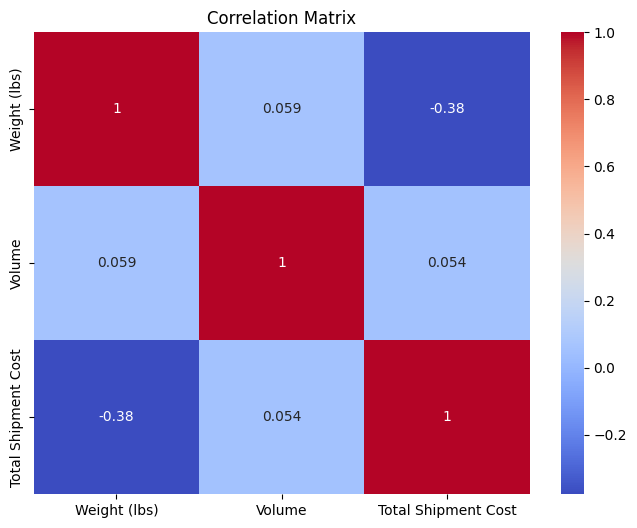

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
numeric_cols = shipment_df.select_dtypes(include=np.number)
plt.figure(figsize=(8,6))
sns.heatmap(numeric_cols.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

In [13]:
carrier_cost = shipment_df.groupby("Carrier Name")["Total Shipment Cost"].agg(["count","mean","median","std"])
carrier_cost

/tmp/ipykernel_1416/2949255476.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  carrier_cost = shipment_df.groupby("Carrier Name")["Total Shipment Cost"].agg(["count","mean","median","std"])


,count,mean,median,std
Carrier Name,,,,
Blue Dart,11,46.704545,25.50,38.049445
DHL,11,51.045455,30.00,40.617241
DTDC,14,42.196429,28.75,37.944567
Delhivery,13,42.365385,25.00,42.562162
Ecom Express,11,48.431818,30.00,41.582462
Ekart Logistics,13,41.019231,25.00,35.236768
FedEx,12,61.979167,42.50,47.504122
Gati,12,50.145833,25.25,44.411359
Safe Express,9,63.250000,50.00,38.750806


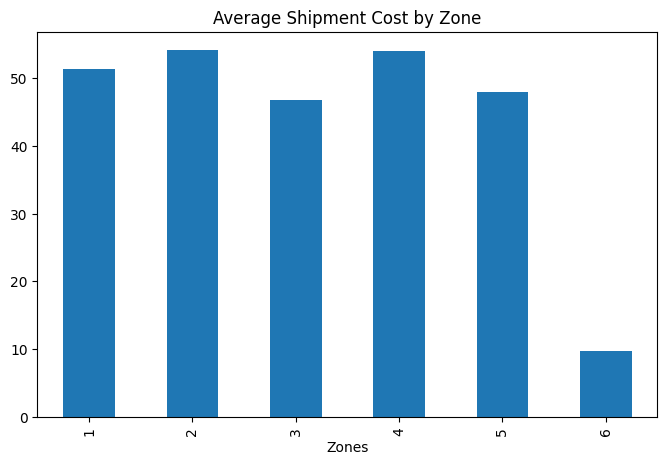

In [14]:
zone_cost = shipment_df.groupby("Zones")["Total Shipment Cost"].mean()
zone_cost.plot(kind="bar", figsize=(8,5))
plt.title("Average Shipment Cost by Zone")
plt.show()

In [23]:
charge_freq = df.groupby("Charge Type")["Tracking Number"].nunique().sort_values(ascending=False)
charge_freq.head(5)

/tmp/ipykernel_1416/1124572295.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  charge_freq = df.groupby("Charge Type")["Tracking Number"].nunique().sort_values(ascending=False)


,Tracking Number
Charge Type,
Additional Tax,5
Adjustment,5
Additional weight charge,3
Additional Vat Charge,3
Adult Signature Required,3


In [87]:
df["rank"] = df.groupby("Tracking Number")["Charge"].rank(method="first", ascending=False)
base_charges = df[df["rank"] == 1]
base_charges.head(3)

,Tracking Number,Carrier Name,Service Level,Zones,Weight (lbs),Dimensions (in),Charge Type,Charge,Pickup Zipcode,Dropoff Zipcode,Date of Delivery,Volume,rank,charge_category
0,1F1234567890123458,Delhivery,Ground,6,11.0,12x12x8,Adult Signature Required,11.25,10005,90001,2024-04-22,1152.0,1.0,surcharge
1,1F1234567890123451,DTDC,Ground,4,5.0,12x12x8,Additional Tax,5.50,60606,90210,2023-08-14,1152.0,1.0,tax
2,1F1234567890123456,Blue Dart,2Day,3,12.0,12x12x8,Adjustment,7.50,60601,90210,2024-01-06,1152.0,1.0,base


In [41]:
total_shipments = df["Tracking Number"].nunique()
print(total_shipments)

106


In [43]:
charge_stats = df.groupby("Charge Type").agg(total_charge=("Charge","sum"), mean_charge=("Charge","mean"), occurrences=("Charge","count"), unique_shipments=("Tracking Number","nunique"))
charge_stats["shipment_ratio"] = (charge_stats["unique_shipments"] / total_shipments)
charge_stats = charge_stats.sort_values("total_charge",ascending=False)
charge_stats.head(10)

/tmp/ipykernel_1416/4250154728.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  charge_stats = df.groupby("Charge Type").agg(


,total_charge,mean_charge,occurrences,unique_shipments,shipment_ratio
Charge Type,,,,,
Adjustment,67.00,13.400000,5,5,0.047170
Additional Tax,60.25,12.050000,5,5,0.047170
Adult Signature Required,57.50,19.166667,3,3,0.028302
Additional Vat Charge,48.00,16.000000,3,3,0.028302
Address Correction,39.50,13.166667,3,3,0.028302
Admin. Fees,39.50,19.750000,2,2,0.018868
Fuel Surcharge,35.00,17.500000,2,2,0.018868
Additional weight charge,33.00,11.000000,3,3,0.028302
Additional Weight Charge,32.00,32.000000,1,1,0.009434


In [49]:
shipment_counts = df.groupby("Tracking Number").size()
shipment_counts.describe()

,0
count,106.000000
mean,2.018868
std,1.466977
min,1.000000
25%,1.000000
50%,1.000000
75%,4.000000
max,5.000000


In [91]:
shipment_cost = df.groupby("Tracking Number").agg(base_cost = ("Charge","max"),additional_cost = ("Charge",lambda x: x.sum()-x.max())).reset_index()
shipment_cost["additional_cost"].fillna(0, inplace=True)
shipment_cost.head()

/tmp/ipykernel_1416/4049632416.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  shipment_cost["additional_cost"].fillna(0, inplace=True)


,Tracking Number,base_cost,additional_cost
0,0F10987POIUY,25.0,0.0
1,0F10987ZXCVB,25.0,75.0
2,0F32109MNBVC,30.0,0.0
3,0F32109POIUY,25.0,0.0
4,0F32109ZXCVB,30.0,0.0


In [99]:
shipment_cost["total_cost"] = (shipment_cost["base_cost"]+ shipment_cost["additional_cost"])
shipment_cost.head()

,Tracking Number,base_cost,additional_cost,total_cost,normalized_cost
0,0F10987POIUY,25.0,0.0,25.0,25.0
1,0F10987ZXCVB,25.0,75.0,100.0,100.0
2,0F32109MNBVC,30.0,0.0,30.0,30.0
3,0F32109POIUY,25.0,0.0,25.0,25.0
4,0F32109ZXCVB,30.0,0.0,30.0,30.0


In [53]:
shipment_meta = df.drop_duplicates("Tracking Number")[["Tracking Number","Carrier Name","Service Level","Zones","Weight (lbs)","Pickup Zipcode","Dropoff Zipcode","Date of Delivery"]]
shipment_meta.head(5)

,Tracking Number,Carrier Name,Service Level,Zones,Weight (lbs),Pickup Zipcode,Dropoff Zipcode,Date of Delivery
0,1F1234567890123458,Delhivery,Ground,6,11.0,10005,90001,2024-04-22
1,1F1234567890123451,DTDC,Ground,4,5.0,60606,90210,2023-08-14
2,1F1234567890123456,Blue Dart,2Day,3,12.0,60601,90210,2024-01-06
3,1F1234567890123459,Delhivery,Ground,6,11.0,10005,90001,2024-04-22
4,1F1234567890123454,FedEx,Next Day Air,1,7.0,10005,90002,2023-11-26


In [54]:
shipment_data = shipment_meta.merge(shipment_cost, on="Tracking Number")
shipment_data.head()

,Tracking Number,Carrier Name,Service Level,Zones,Weight (lbs),Pickup Zipcode,Dropoff Zipcode,Date of Delivery,total_cost
0,1F1234567890123458,Delhivery,Ground,6,11.0,10005,90001,2024-04-22,11.25
1,1F1234567890123451,DTDC,Ground,4,5.0,60606,90210,2023-08-14,5.50
2,1F1234567890123456,Blue Dart,2Day,3,12.0,60601,90210,2024-01-06,7.50
3,1F1234567890123459,Delhivery,Ground,6,11.0,10005,90001,2024-04-22,11.25
4,1F1234567890123454,FedEx,Next Day Air,1,7.0,10005,90002,2023-11-26,9.00


In [56]:
shipment_data["Zones"] = shipment_data["Zones"].astype(float)
shipment_data["cost_per_lb"] = (shipment_data["total_cost"] /shipment_data["Weight (lbs)"])
shipment_data["cost_per_zone"] = (shipment_data["total_cost"] /shipment_data["Zones"])
shipment_data["cost_per_lb_zone"] = (shipment_data["total_cost"] /(shipment_data["Weight (lbs)"] * shipment_data["Zones"]))

In [57]:
carrier_comparison = shipment_data.groupby("Carrier Name")[["total_cost","cost_per_lb","cost_per_zone","cost_per_lb_zone"]].mean().sort_values("cost_per_lb_zone")
carrier_comparison

/tmp/ipykernel_1416/3087243555.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  carrier_comparison = shipment_data.groupby("Carrier Name")[["total_cost","cost_per_lb","cost_per_zone","cost_per_lb_zone"]].mean().sort_values("cost_per_lb_zone")


,total_cost,cost_per_lb,cost_per_zone,cost_per_lb_zone
Carrier Name,,,,
Delhivery,42.365385,9.239073,10.864103,2.370134
Blue Dart,46.704545,11.075000,12.656818,2.882576
FedEx,61.979167,13.500198,13.536806,2.893948
Ekart Logistics,41.019231,9.941453,14.144231,3.387917
DHL,51.045455,12.327652,20.054924,4.882576
Ecom Express,48.431818,11.638258,24.871212,5.861742
Safe Express,63.250000,14.340278,30.118056,6.793403
DTDC,42.196429,10.030952,38.251488,9.196974
Gati,50.145833,12.412698,48.468750,12.015129


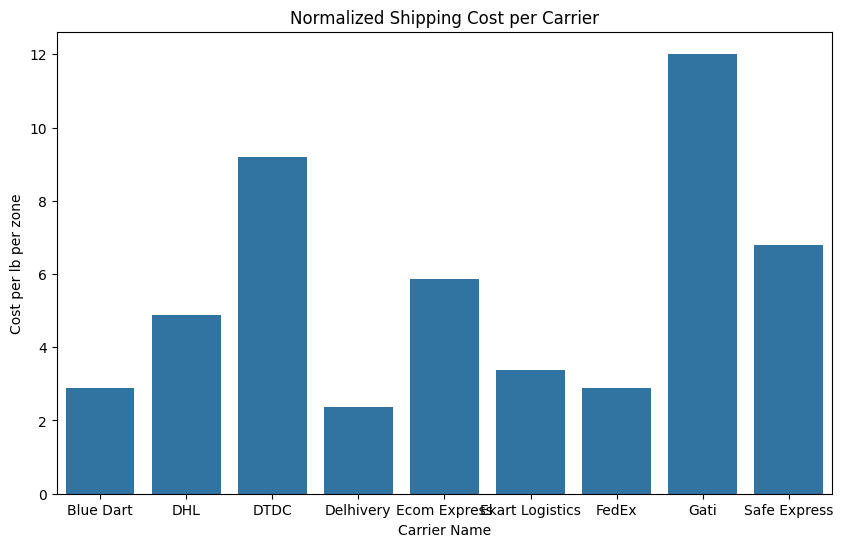

In [58]:
plt.figure(figsize=(10,6))
sns.barplot(data=carrier_comparison.reset_index(),x="Carrier Name",y="cost_per_lb_zone")
plt.title("Normalized Shipping Cost per Carrier")
plt.ylabel("Cost per lb per zone")
plt.show()

In [71]:
carrier_service = shipment_data.groupby(
    ["Carrier Name","Service Level"])["cost_per_lb_zone"].mean().reset_index()
carrier_service = carrier_service.dropna()
carrier_service.sort_values("cost_per_lb_zone")

/tmp/ipykernel_1416/4631627.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  carrier_service = shipment_data.groupby(


,Carrier Name,Service Level,cost_per_lb_zone
40,Ekart Logistics,2Day,0.145000
28,Delhivery,Ground,0.159470
0,Blue Dart,2Day,0.208333
45,Ekart Logistics,Next Day Air,0.255556
52,FedEx,Ground,0.258333
16,DTDC,2Day,0.263889
20,DTDC,Ground,0.309375
29,Delhivery,Next Day Air,0.416667
13,DHL,Next Day Air,0.500000
60,Gati,Ground,0.520833


In [65]:
carrier_raw = shipment_data.groupby("Carrier Name")["total_cost"].mean()
carrier_norm = shipment_data.groupby("Carrier Name")["cost_per_lb_zone"].mean()
comparison = pd.concat([carrier_raw,carrier_norm], axis=1)
comparison.columns = ["avg_total_cost","normalized_cost"]
comparison

/tmp/ipykernel_1416/816211851.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  carrier_raw = shipment_data.groupby("Carrier Name")["total_cost"].mean()
/tmp/ipykernel_1416/816211851.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  carrier_norm = shipment_data.groupby("Carrier Name")["cost_per_lb_zone"].mean()


,avg_total_cost,normalized_cost
Carrier Name,,
Blue Dart,46.704545,2.882576
DHL,51.045455,4.882576
DTDC,42.196429,9.196974
Delhivery,42.365385,2.370134
Ecom Express,48.431818,5.861742
Ekart Logistics,41.019231,3.387917
FedEx,61.979167,2.893948
Gati,50.145833,12.015129
Safe Express,63.250000,6.793403


In [100]:
threshold = shipment_data["cost_per_lb_zone"].quantile(0.90)
threshold

np.float64(12.71875)

In [102]:
worst_shipments = shipment_data[shipment_data["cost_per_lb_zone"] >= threshold]
worst_shipments

,Tracking Number,Carrier Name,Service Level,Zones,Weight (lbs),Volume,base_cost,additional_cost,total_cost,normalized_cost,cost_per_lb_zone
27,2F76543POIUY,DHL,Priority,1.0,4.0,1152.0,26.75,25.0,51.75,51.75,12.9375
74,2F76543LKJHG,Ecom Express,Ground,2.0,4.0,1152.0,25.00,100.0,125.00,125.00,15.6250
76,4F10987ZXCVB,Gati,Standard,1.0,4.0,1152.0,30.00,100.0,130.00,130.00,32.5000
81,6F43210MNBVC,Safe Express,Economy,2.0,5.0,1152.0,30.00,100.0,130.00,130.00,13.0000
83,8F76543LKJHG,DTDC,Express,1.0,4.0,1152.0,25.00,100.0,125.00,125.00,31.2500
87,2F43210MNBVC,Gati,Standard,1.0,4.0,1152.0,25.00,75.0,100.00,100.00,25.0000
92,7F76543LKJHG,DTDC,Express,1.0,4.0,1152.0,25.00,75.0,100.00,100.00,25.0000
94,9F10987ZXCVB,Ecom Express,Ground,2.0,4.0,1152.0,30.00,75.0,105.00,105.00,13.1250
96,1F43210MNBVC,Gati,Standard,1.0,4.0,1152.0,30.00,75.0,105.00,105.00,26.2500
101,6F76543LKJHG,DTDC,Express,1.0,4.0,1152.0,25.00,75.0,100.00,100.00,25.0000


In [103]:
len(worst_shipments) / len(shipment_data)

0.10377358490566038

In [104]:
carrier_concentration = worst_shipments["Carrier Name"].value_counts(normalize=True) * 100
carrier_concentration

,proportion
Carrier Name,
Gati,36.363636
DTDC,27.272727
Ecom Express,18.181818
Safe Express,9.090909
DHL,9.090909
Blue Dart,0.000000
Delhivery,0.000000
FedEx,0.000000
Ekart Logistics,0.000000


In [105]:
zone_concentration = worst_shipments["Zones"].value_counts(normalize=True) * 100
zone_concentration

,proportion
Zones,
1.0,72.727273
2.0,27.272727


In [106]:
service_concentration = worst_shipments["Service Level"].value_counts(normalize=True) * 100
service_concentration

,proportion
Service Level,
Standard,36.363636
Express,27.272727
Ground,18.181818
Economy,9.090909
Priority,9.090909
2Day,0.000000
Expedited,0.000000
Next Day Air,0.000000


In [107]:
total_spend = shipment_data["total_cost"].sum()
worst_spend = worst_shipments["total_cost"].sum()
worst_share = worst_spend / total_spend * 100
worst_share

np.float64(22.544492544492545)

In [108]:
shipment_data["total_cost"].mean(), worst_shipments["total_cost"].mean()

(np.float64(49.033018867924525), np.float64(106.52272727272727))

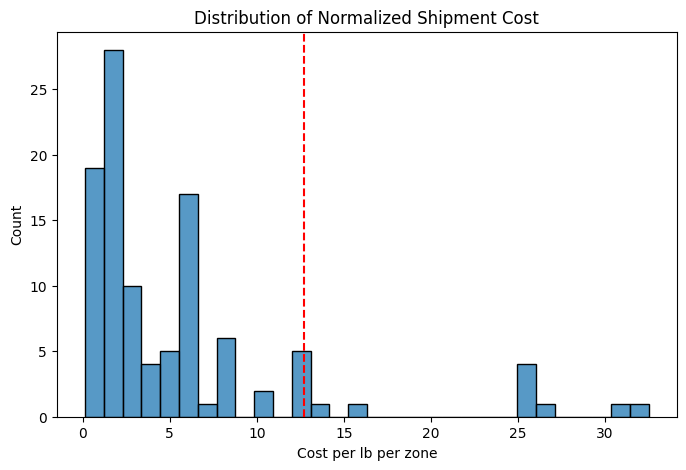

In [109]:
plt.figure(figsize=(8,5))
sns.histplot(shipment_data["cost_per_lb_zone"], bins=30)
plt.axvline(threshold, color="red", linestyle="--")
plt.title("Distribution of Normalized Shipment Cost")
plt.xlabel("Cost per lb per zone")
plt.show()